# 2주차 실습: CIFAR-10 Nearest Neighbor Classifier

**목표:** CIFAR-10 이미지 데이터셋에서 1-Nearest Neighbor Classifier를 직접 구현합니다.

**데이터:** CIFAR-10 — 10개 클래스, 32×32 컬러 이미지  
(airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)

## 0. 라이브러리 불러오기

In [3]:
import numpy as np
import torchvision
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt

## 1. 데이터 로드

torchvision으로 CIFAR-10을 다운로드한 뒤, 이후 실습에서 쓰기 편한 형태로 변환합니다.  
각 이미지는 `[R채널 1024개, G채널 1024개, B채널 1024개]` 순서의 1D 배열(serial)로 저장됩니다.

In [4]:
def load_cifar10(train=True):
    """
    torchvision으로 CIFAR-10을 다운로드하고
    (N, 3072) serial 배열과 레이블 배열을 반환합니다.
    """
    dataset = torchvision.datasets.CIFAR10(
        root='.', train=train, download=False
    )

    data = dataset.data
    serials = np.concatenate([
        data[:, :, :, 0].reshape(-1, 1024),
        data[:, :, :, 1].reshape(-1, 1024),
        data[:, :, :, 2].reshape(-1, 1024),
    ], axis=1)

    labels = np.array(dataset.targets)

    return serials, labels


train_serials, train_labels = load_cifar10(train=True)
test_serials,  test_labels  = load_cifar10(train=False)

print(train_serials.shape)


(50000, 3072)


## 2. 이미지 시각화

1D serial 배열을 32×32 컬러 이미지로 복원하는 함수입니다.

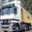

In [5]:
def serial2image(serial):
    """
    serial: (3072,) 배열 — R 1024개, G 1024개, B 1024개 순서
    각 채널을 (32, 32)로 reshape한 뒤 (32, 32, 3) 이미지로 합쳐 반환합니다.
    """
    red   = serial[:1024].reshape(32, 32)
    green = serial[1024:2048].reshape(32, 32)
    blue  = serial[2048:].reshape(32, 32)

    return np.stack([red, green, blue], axis=2)


i = 1
display(Image.fromarray(serial2image(train_serials[i])))


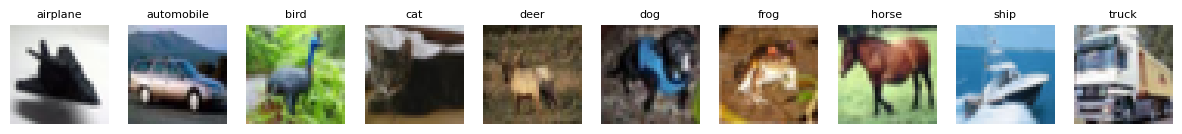

In [6]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']

# TODO: 클래스별로 이미지를 1장씩 골라 가로로 10개 출력해보세요
# 각 이미지 위에 클래스 이름을 제목으로 달아보세요
# 힌트: np.where(train_labels == i)[0][0] 으로 클래스 i의 첫 번째 index를 찾을 수 있어요

plt.figure(figsize=(15, 2))
for i in range(10):
    idx = np.where(train_labels == i)[0][0]
    plt.subplot(1, 10, i + 1)
    plt.imshow(serial2image(train_serials[idx]))
    plt.title(class_names[i], fontsize=8)
    plt.axis('off')
plt.show()

## 3. train / predict 인터페이스

머신러닝 모델의 기본 구조를 함수로 먼저 정의합니다.  
`train`은 학습 데이터를 받아 모델을 반환하고, `predict`는 모델로 레이블을 예측합니다.

In [7]:
def train(images, labels):
    return Model(images, labels)


def predict(model, test_images):
    return model(test_images)

## 4. Model 클래스 구현

`__init__`: 학습 이미지와 레이블을 저장합니다.  
`__call__`: 테스트 이미지 목록을 받아 각각 `predict`를 호출합니다.  
`predict`: 테스트 이미지 1장과 가장 가까운 학습 이미지의 레이블을 반환합니다. ← **핵심 구현**

In [8]:
class Model:
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __call__(self, test_images):
        return [self.predict(image) for image in test_images]

    def predict(self, image):
        """
        image: (3072,) 배열 — 테스트 이미지 1장
        학습 이미지 전체와 거리를 계산해서 가장 가까운 이미지의 레이블을 반환하세요.
        """
        num_images = self.images.shape[0]

        distances = np.abs(self.images - image).sum(axis=1)

        idx = np.argmin(distances)

        return self.labels[idx]

## 5. 구현 확인: 학습 데이터로 테스트

학습 데이터로 예측하면 자기 자신이 가장 가까우므로 정확도가 100%여야 합니다.

In [9]:
# 작은 subset으로 먼저 확인 (속도)
images = train_serials[:1000].astype(float)
labels = train_labels[:1000]

model = train(images, labels)
test_labels_sanity = predict(model, images[:10])

print("예측:", test_labels_sanity)
print("정답:", list(model.labels[:10]))
# 두 줄이 같아야 합니다

예측: [np.int64(6), np.int64(9), np.int64(9), np.int64(4), np.int64(1), np.int64(1), np.int64(2), np.int64(7), np.int64(8), np.int64(3)]
정답: [np.int64(6), np.int64(9), np.int64(9), np.int64(4), np.int64(1), np.int64(1), np.int64(2), np.int64(7), np.int64(8), np.int64(3)]


## 6. 테스트 데이터로 정확도 측정

⚠️ 학습 5,000장 × 테스트 500장 계산이므로 수 분이 걸릴 수 있습니다.

In [10]:
# 학습 데이터 5,000장, 테스트 데이터 500장 사용
model = train(train_serials[:5000].astype(float), train_labels[:5000])

predictions = predict(model, test_serials[:500].astype(float))

accuracy = np.mean(np.array(predictions) == test_labels[:500])
print(f"1-NN 정확도: {accuracy:.1%}")

1-NN 정확도: 29.0%


## 7. 결과 시각화: 틀린 케이스 분석

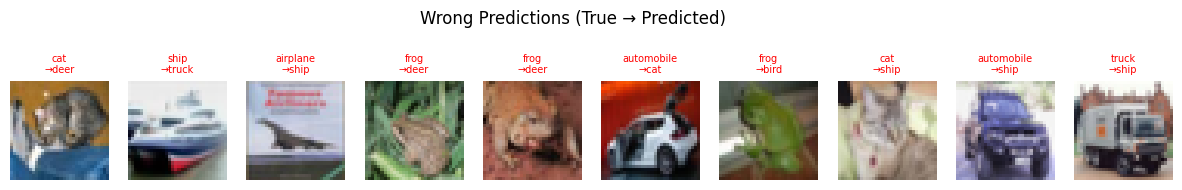

In [11]:
predictions = np.array(predictions)
ground_truth = test_labels[:500]

wrong_indices = np.where(predictions != ground_truth)[0]

# 틀린 케이스 10개 시각화
plt.figure(figsize=(15, 2))
for i, idx in enumerate(wrong_indices[:10]):
    plt.subplot(1, 10, i + 1)
    plt.imshow(serial2image(test_serials[idx]))
    true_label = class_names[ground_truth[idx]]
    pred_label = class_names[predictions[idx]]
    plt.title(f"{true_label}\n→{pred_label}", fontsize=7, color='red')
    plt.axis('off')
plt.suptitle('Wrong Predictions (True → Predicted)', y=1.1)
plt.show()

## 8. 생각해보기 💬

Gemini에게 아래 질문을 던져보세요:

1. pixel 거리로 이미지를 비교하는 방식의 한계는 무엇인가요?
2. `(self.images - image)` 계산 시 uint8 타입 그대로 쓰면 어떤 문제가 생길까요? `.astype(float)`은 왜 필요한가요?
3. 학습 데이터를 5,000장에서 50,000장으로 늘리면 정확도와 속도는 어떻게 달라질까요?

## 도전 과제 ⭐

- **L2 distance:** `predict` 안의 거리 계산을 L2로 바꿔보고 정확도를 비교해보세요
- **K-NN:** `predict`를 수정해서 가장 가까운 k개의 이웃 중 다수결로 예측하도록 만들어보세요